In [26]:
# !pip install torch torchvision torchaudio

In [3]:
import torch
from torch import nn
from torch.nn import functional as F


In [4]:
from pathlib import Path
import requests

DATA_PATH = Path("data")
PATH = DATA_PATH / "mnist"

PATH.mkdir(parents=True, exist_ok=True)

URL = "https://github.com/pytorch/tutorials/raw/main/_static/"
FILENAME = "mnist.pkl.gz"

if not (PATH / FILENAME).exists():
        content = requests.get(URL + FILENAME).content
        (PATH / FILENAME).open("wb").write(content)

In [5]:
import pickle
import gzip

with gzip.open((PATH / FILENAME).as_posix(), "rb") as f:
        ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")

/tmp/ipykernel_46924/2203444482.py:5: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")


In [8]:
print(x_train.shape, y_train.shape)

(50000, 784) (50000,)


In [11]:
type(x_train[0])

numpy.ndarray

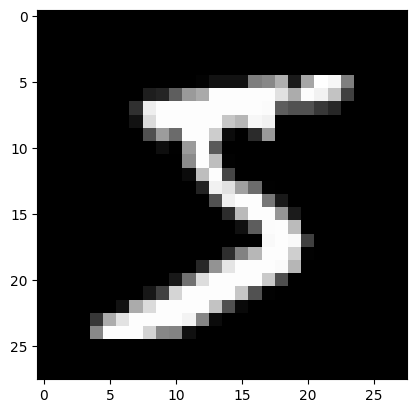

(50000, 784)


In [9]:
from matplotlib import pyplot
import numpy as np

pyplot.imshow(x_train[0].reshape((28, 28)), cmap="gray")
# ``pyplot.show()`` only if not on Colab
try:
    import google.colab
except ImportError:
    pyplot.show()
print(x_train.shape)

In [12]:
x_train, y_train, x_valid, y_valid= map(torch.tensor, (x_train, y_train, x_valid, y_valid))

In [14]:
type(x_train)
print(x_train.shape)

torch.Size([50000, 784])


In [15]:
import math

weights= torch.randn(784, 10)/ math.sqrt(784)   # xavier initialization

weights.requires_grad_()

bias= torch.zeros(10, requires_grad=True)


In [17]:
weights.shape, bias.shape

(torch.Size([784, 10]), torch.Size([10]))

In [19]:
# loss function

def log_softmax(x):
    return x- x.exp().sum(-1).log().unsqueeze(-1)
    # x.exp().sum(-1).log() is the log of the sum of the
    #  exponentials of x along the last dimension, which is
    #  used for numerical stability in softmax calculations.
    #  The unsqueeze(-1) adds an extra dimension to make it
    #  compatible for broadcasting when subtracting from x.

def model(xb):
    return log_softmax(xb @ weights + bias)

In [20]:
bs= 64

xb= x_train[0:bs]
preds= model(xb)

preds[0], preds.shape

(tensor([-1.8767, -2.3685, -2.2345, -2.5534, -2.0288, -2.7245, -2.4580, -1.9848,
         -2.3621, -2.9167], grad_fn=<SelectBackward0>),
 torch.Size([64, 10]))

In [21]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__() # super init will initialize the nn.Module part of the class
        self.flatten= nn.Flatten()
        self.linear_layer= nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )
    def forward(self, x):
        x= self.flatten(x)
        logits= self.linear_layer(x)
        return F.log_softmax(logits, dim=1)

In [22]:
model= NeuralNetwork().to("cuda")
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_layer): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [24]:
X= torch.rand(1,28,28, device="cuda")
logits= model(X)

pred_prob= nn.Softmax(dim=1)(logits) ## dim=1 means we want to apply softmax to the last dimension of the logits tensor,
                               # which corresponds to the class scores. This will convert the logits 
                               # into probabilities for each class.
y_pred= pred_prob.argmax(dim=1)
print(f"predicted class: {y_pred}, predicted probabilities: {pred_prob}")

predicted class: tensor([9], device='cuda:0'), predicted probabilities: tensor([[0.1073, 0.0992, 0.1037, 0.1032, 0.0882, 0.0979, 0.0950, 0.0959, 0.1022,
         0.1074]], device='cuda:0', grad_fn=<SoftmaxBackward0>)


In [25]:
print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

Model structure: NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_layer): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Layer: linear_layer.0.weight | Size: torch.Size([512, 784]) | Values : tensor([[ 0.0180, -0.0146,  0.0357,  ..., -0.0245, -0.0006,  0.0276],
        [ 0.0278,  0.0341,  0.0340,  ...,  0.0186, -0.0222, -0.0197]],
       device='cuda:0', grad_fn=<SliceBackward0>) 

Layer: linear_layer.0.bias | Size: torch.Size([512]) | Values : tensor([ 0.0158, -0.0267], device='cuda:0', grad_fn=<SliceBackward0>) 

Layer: linear_layer.2.weight | Size: torch.Size([512, 512]) | Values : tensor([[-0.0218, -0.0031,  0.0059,  ...,  0.0114,  0.0112, -0.0334],
        [-0.0341,  0.0315, -0.0162,  ...,  0.0376,  0.0439,  0.0156]],
       device='cuda:0', grad_fn=<SliceBackward0>) 

Lay